<a id="table-of-contents"></a>
# Module 2: Equations of Lines, Quadratics, and More Functions

## Table of Contents
- [2.1 Equations of Lines and Quadratics](#21-equations-of-lines-and-quadratics)
  - [2.1.1 Equations of Lines](#211-equations-of-lines)
    - [Slope (Linear Equation)](#slope)
    - [Parallel Lines](#parallel-lines)
    - [Perpendicular Lines](#perpendicular-lines)
  - [2.1.2 Quadratic Functions](#212-quadratic-functions)
    - [Parabolas (Standard Form)](#parabolas)
    - [Vertex](#vertex)
    - [The Quadratic Formula](#quadratic-formula)
    - [System of Equations Intersection](#system-of-equations)
- [2.2 Advanced Function Operations](#22-advanced-function-operations)
  - [2.2.1 Function Composition](#function-composition)
  - [2.2.2 Inverse Functions](#inverse-functions)
    - [One-to-One & Horizontal Line Test (HLT)](#one-to-one-and-hlt)
    - [Algebraic Derivation of Inverse](#algebraic-derivation-of-inverse)

In [31]:
# import Pkg
# Pkg.add(["Plots", "PlotlyJS", "PlotlyBase", "PlotlyKaleido" , "SymPy"])
using Plots
using SymPy
# Activate the interactive Plotly backend
gr(fmt = :svg)
gr()
# I used plotly() btw

Plots.GRBackend()

In [32]:
# Fix Plot Code
function get_domain(center; margin_factor=2, base_margin=2)
    margin = margin_factor * abs(center) + base_margin
    x_left  = center - margin
    x_right = center + margin
    return x_left:0.1:x_right, x_left, x_right
end

get_domain (generic function with 1 method)

<a id="21-equations-of-lines-and-quadratics"></a>
## 2.1 Equations of Lines and Quadratics

<a id="211-equations-of-lines"></a>
### 2.1.1 Equations of Lines

<a id="slope"></a>
#### 2.1.1.1 Slope (Linear Equation)

**Mathematical Concept:**
A linear equation in slope-intercept form defines a straight line, where $m$ dictates the rate of change and $b$ represents the initial state (y-intercept).
$$ y = mx + b $$

**Modeling Objective:**
Programmatically extract a linear model from two discrete points and visually isolate the y-intercept parameter.

[↑ Back to Table of Contents](#table-of-contents)

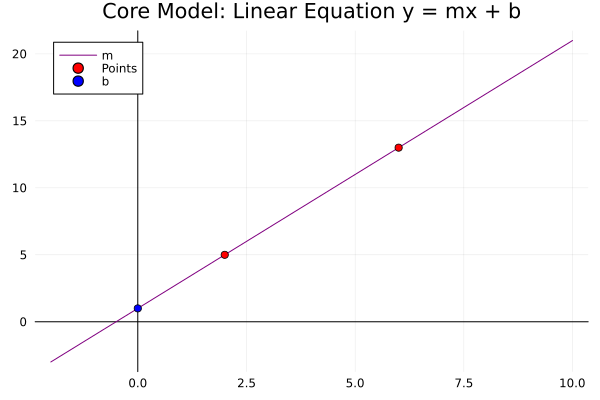

In [33]:
p1 = (x1, y1) = (2.0, 5.0)
p2 = (x2, y2) = (6.0, 13.0)

m = (y2 - y1) / (x2 - x1)
b = y1 - m * x1
line_model(x) = m * x + b
x_range = -2:0.1:10

plot(x_range, line_model.(x_range), 
     title="Core Model: Linear Equation y = mx + b",
     label="m",
     color=:purple,
     framestyle=:zerolines,)

scatter!([x1, x2], [y1, y2], 
         color=:red,
         label="Points")

scatter!([0],[b],
         color=:blue,
         label="b")

<a id="parallel-lines"></a>
#### 2.1.1.2 Parallel Lines

**Mathematical Concept:**
Two discrete linear functions are parallel if they possess identical rates of change (slopes) but different y-intercepts.
$$ m_1 = m_2 $$

**Modeling Objective:**
Geometrically render two non-intersecting line segments to visualize equivalent linear trajectories.

[↑ Back to Table of Contents](#table-of-contents)

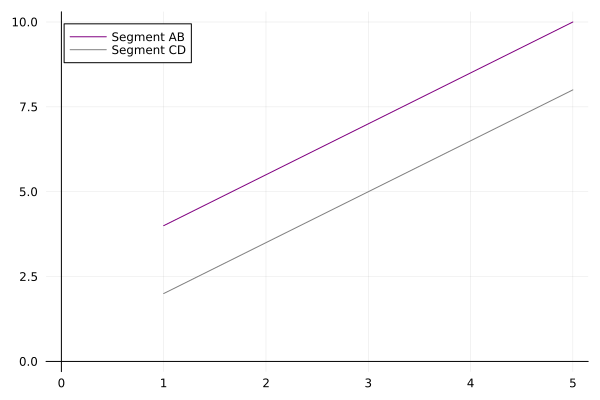

In [34]:
A = (x1, y1) = (1.0, 4.0)
B = (x2, y2) = (5.0, 10.0)

plot([x1, x2], [y1, y2], 
      label="Segment AB", 
      color=:purple,)

C = (a1, b1) = (x1, 2.0)
D = (a2, b2) = (x2, 8.0)

plot!([a1, a2], [b1, b2], 
      label="Segment CD", 
      color=:gray,
      framestyle=:zerolines)




<a id="slope-calculation"></a>
#### Slope Calculation Proof

**Mathematical Concept:**
Calculating the exact gradient confirms parallelism mathematically rather than relying strictly on visual intuition.
$$ m_{AB} = \frac{10-4}{5-1} = 1.5 \quad , \quad m_{CD} = \frac{8-2}{5-1} = 1.5 $$

**Modeling Objective:**
Numerically validate that both plotted segments share identical slopes.

[↑ Back to Table of Contents](#table-of-contents)

<a id="perpendicular-lines"></a>
#### 2.1.1.3 Perpendicular Lines

**Mathematical Concept:**
Lines are orthogonal (perpendicular) if their slopes are negative reciprocals of one another, forming a 90-degree intersection.
$$ m_1 = -\frac{1}{m_2} $$

**Modeling Objective:**
Visualize orthogonal trajectories in a Cartesian coordinate system.

[↑ Back to Table of Contents](#table-of-contents)

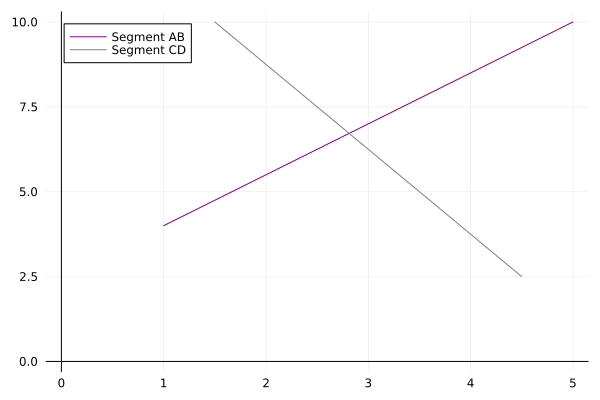

In [35]:
A = (x1, y1) = (1.0, 4.0)
B = (x2, y2) = (5.0, 10.0)

plot([x1, x2], [y1, y2], 
      label="Segment AB", 
      color=:purple,)

C = (a1, b1) = (x1+0.5, y1*2.5)
D = (a2, b2) = (x2-0.5, y2/4)

plot!([a1, a2], [b1, b2], 
      label="Segment CD", 
      color=:gray,
      framestyle=:zerolines)

# I know the angle is not 90 degree, But i tried


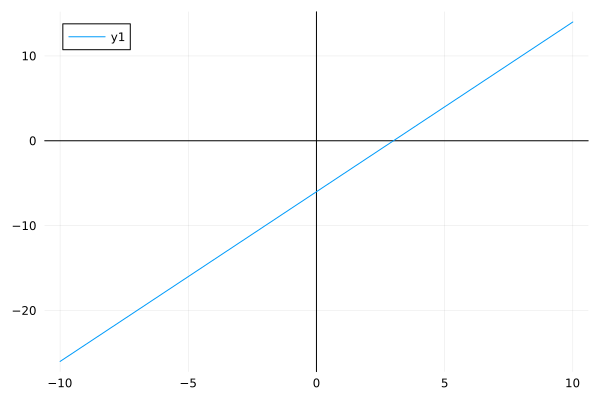

In [36]:
h(x) = 2x - 6
x = -10:1:10

plot(x,h,framestyle=:zerolines )

# or 

# Ha?

<a id="212-quadratic-functions"></a>
### 2.1.2 Quadratic Functions

<a id="parabolas"></a>
#### 2.1.2.1 Parabolas (Standard Form)

**Mathematical Concept:**
A quadratic equation outlines a parabola. Alterations to constants shift the curve spatially across the coordinate plane.
$$ f(x) = ax^2 + bx + c $$

**Modeling Objective:**
Demonstrate horizontal and vertical translations (shifts) utilizing symbolic mathematical definitions.

[↑ Back to Table of Contents](#table-of-contents)

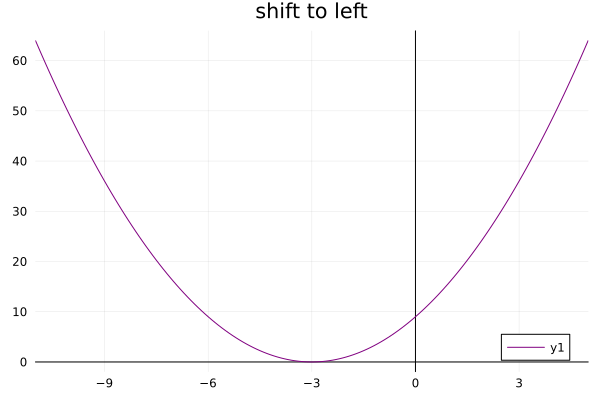

In [37]:
@syms x
# let c > 0
c = 3
f = (x + c)^2

x_domain, x_left, x_right = get_domain(-c)

plot(x_domain,f, title="shift to left" , color=:purple, framestyle=:zerolines,
 xlims = (x_left, x_right))

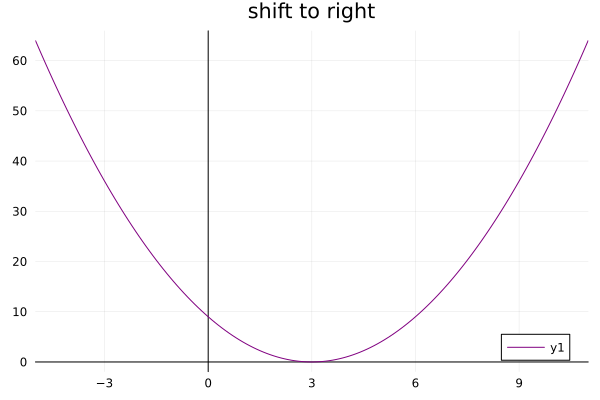

In [38]:
@syms x
# let c > 0
c = 3
f = (x - c)^2

x_domain, x_left, x_right = get_domain(+c)

plot(x_domain,f, title="shift to right" , color=:purple, framestyle=:zerolines,
 xlims = (x_left, x_right))

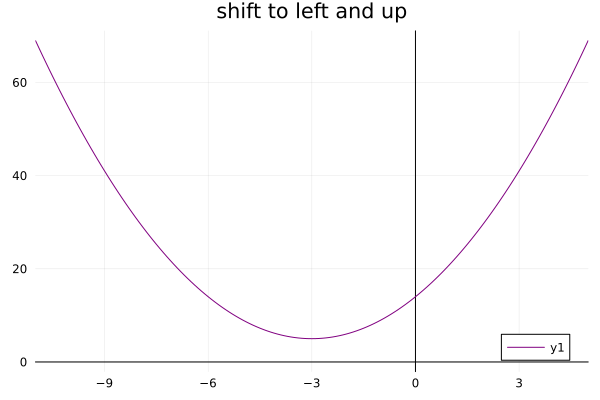

In [39]:
@syms x
# let c > 0
c = 3
f = (x + c)^2 + 5

x_domain, x_left, x_right = get_domain(-c)

plot(x_domain,f, title="shift to left and up" , color=:purple, framestyle=:zerolines,
 xlims = (x_left, x_right))

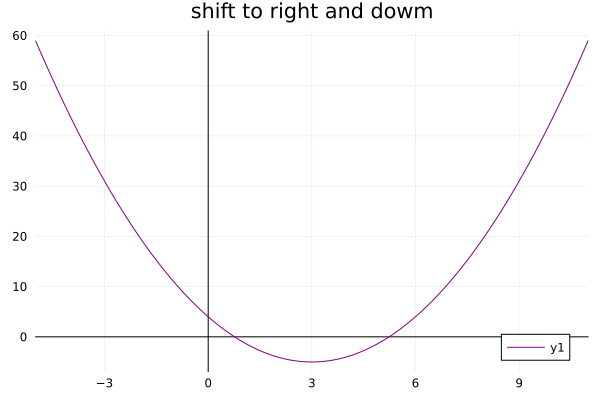

In [40]:
@syms x
# let c > 0
c = 3
f = (x - c)^2 - 5

x_domain, x_left, x_right = get_domain(+c)

plot(x_domain,f, title="shift to right and dowm" , color=:purple, framestyle=:zerolines,
 xlims = (x_left, x_right))

<a id="vertex"></a>
#### 2.1.2.2 Parabola Vertex

**Mathematical Concept:**
The vertex is the singular extremum (minimum or maximum) of a parabola, calculated via derivative logic relative to coefficients.
$$ V(x, y) = \left( -\frac{b}{2a}, \frac{4ac - b^2}{4a} \right) $$

**Modeling Objective:**
Programmatically evaluate polynomial coefficients to strictly isolate and plot the function's turning point.

[↑ Back to Table of Contents](#table-of-contents)

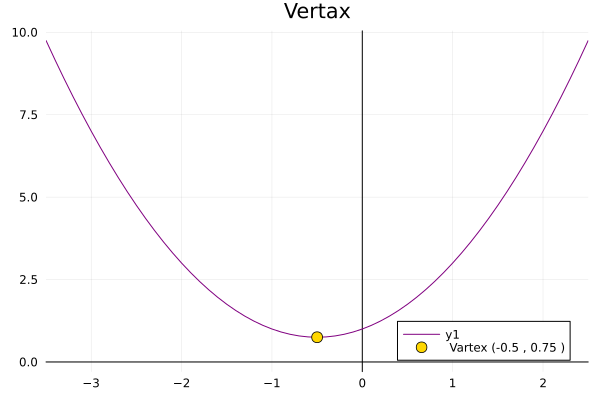

In [41]:
@syms x

f = x^2 + x + 1
a = Float64(f.coeff(x,2))
b = Float64(f.coeff(x,1))
c = Float64(f.coeff(x,0))
vx = -b/2a
vy = Float64(f(x => vx))

x_domain, x_left, x_right = get_domain(vx)

plot(x_domain,f, title="Vertax" , color=:purple, framestyle=:zerolines,
 xlims = (x_left, x_right))

scatter!([vx],[vy] , color=:gold, ms=6, label=" Vartex ($vx , $vy )")


<a id="quadratic-formula"></a>
#### 2.1.2.3 The Quadratic Formula

**Mathematical Concept:**
Used to identify the specific roots (x-intercepts) of a quadratic function where $y = 0$.
$$ x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a} $$

**Modeling Objective:**
Harness symbolic computation (`SymPy`) to algebraically resolve exact roots and visually pinpoint them on the axis.

[↑ Back to Table of Contents](#table-of-contents)

In [42]:
@syms x a b c

f_general = a*x^2 + b*x + c

roots_sym = solve(f_general, x)

2-element Vector{Sym{PyCall.PyObject}}:
 (-b - sqrt(-4*a*c + b^2))/(2*a)
 (-b + sqrt(-4*a*c + b^2))/(2*a)

In [43]:
@syms x

f = 4x^2 + -4x + 1
roots= solve(f,x)

1-element Vector{Sym{PyCall.PyObject}}:
 1/2

In [44]:
@syms x

f = x^2 + -4x + 1
roots= solve(f,x)

2-element Vector{Sym{PyCall.PyObject}}:
 2 - √3
 √3 + 2

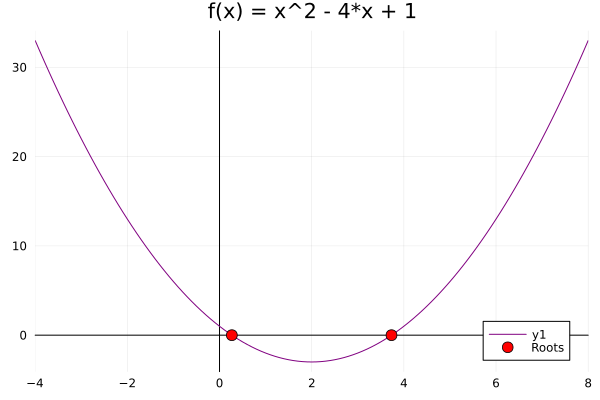

In [45]:
@syms x
f = x^2 + -4x + 1

roots = solve(f, x)

r1 = Float64(roots[1])
r2 = Float64(roots[2])

a = Float64(f.coeff(x, 2))
b = Float64(f.coeff(x, 1))
vx = -b / (2*a)

x_domain, x_left, x_right = get_domain(vx)

plot(x_domain, f, title="f(x) = $f", color=:purple, framestyle=:zerolines, xlims=(x_left, x_right))

scatter!([r1, r2], [0, 0], color=:red, ms=6, label="Roots")

<a id="system-of-equations"></a>
#### 2.1.2.4 System of Equations Intersection

**Mathematical Concept:**
Solving two simultaneous equations identifies precise spatial coordinates where diverse mathematical models geometrically intersect.
$$ 2x^2 - 5x - 6 = 3x + 4 $$

**Modeling Objective:**
Symbolically equate linear and quadratic functions to predict intersection anomalies dynamically.

[↑ Back to Table of Contents](#table-of-contents)

In [46]:
@syms x y

eq1 = SymPy.Eq(y, 2*x^2 - 5*x - 6)
eq2 = SymPy.Eq(y, 3*x + 4)

solutions = solve([eq1, eq2], (x, y))

2-element Vector{Tuple{Sym{PyCall.PyObject}, Sym{PyCall.PyObject}}}:
 (-1, 1)
 (5, 19)

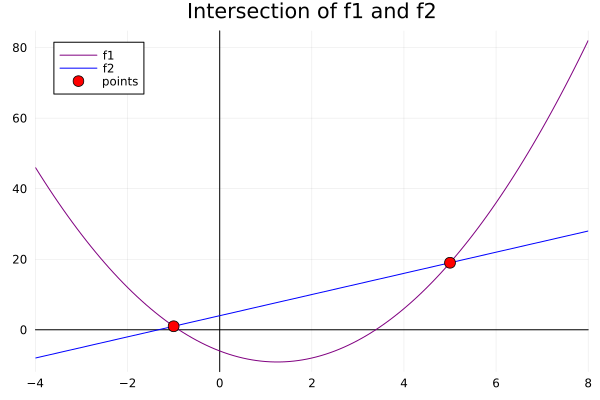

In [47]:
@syms x y
f1 = 2x^2 - 5x - 6
f2 = 3x + 4

f = f1 - f2  
a = Float64(f.coeff(x,2))
b = Float64(f.coeff(x,1))
c = Float64(f.coeff(x,0))
vx = -b/2a

x_domain, x_left, x_right = get_domain(vx)

eq1 = SymPy.Eq(y, 2*x^2 - 5*x - 6)
eq2 = SymPy.Eq(y, 3*x + 4)

sol = solve([eq1, eq2], (x, y))
v1 = sol[1]
v2 = sol[2]
va1 = v1[1]
va2 = v1[2]
vb1 = v2[1]
vb2 = v2[2]

plot(x_domain, f1, title="Intersection of f1 and f2", color=:purple, label="f1", framestyle=:zerolines, xlims=(x_left, x_right))
plot!(x_domain, f2, color=:blue, label="f2")
scatter!([va1,vb1] , [va2,vb2] , color=:red, ms=6, label="points")


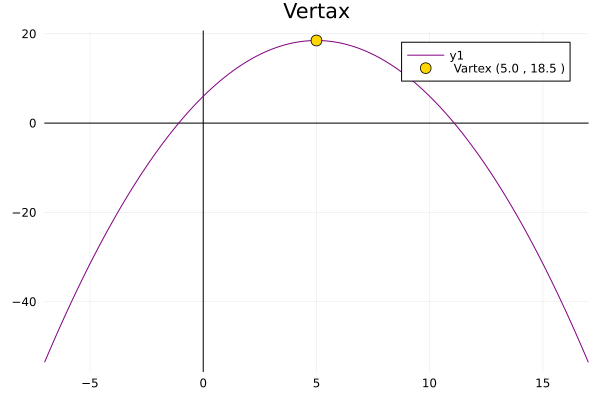

In [48]:
@syms x

f = 6 + 5x - (1/2) * x^2
a = Float64(f.coeff(x,2))
b = Float64(f.coeff(x,1))
c = Float64(f.coeff(x,0))
vx = -b/2a
vy = Float64(f(x => vx))

x_domain, x_left, x_right = get_domain(vx)

plot(x_domain,f, title="Vertax" , color=:purple, framestyle=:zerolines,
 xlims = (x_left, x_right))

scatter!([vx],[vy] , color=:gold, ms=6, label=" Vartex ($vx , $vy )")

<a id="22-advanced-function-operations"></a>
## 2.2 Advanced Function Operations

<a id="function-composition"></a>
### 2.2.1 Function Composition

**Mathematical Concept:**
Composition evaluates one function using another function's output as its intrinsic input, cascading the mappings sequentially.
$$ (f \circ g)(x) = f(g(x)) \quad \text{and} \quad (g \circ f)(x) = g(f(x)) $$

**Modeling Objective:**
Prove non-commutative system behavior algebraically and execute nested computational sub-routines cleanly.

[↑ Back to Table of Contents](#table-of-contents)

In [49]:
f_func(x) = x^2
g_func(x) = x + 1

hx = f_func ∘ g_func

result = hx(3)

16

In [50]:
@syms x

f = x^2
g = x + 1

result_sym = f(x => g) 

       2
(x + 1) 

<a id="composition-examples"></a>
#### Composition Examples

In [51]:
@syms x

f = sqrt(x+4)
result_sym = f(x => f)

   _______________
  ╱   _______     
╲╱  ╲╱ x + 4  + 4 

In [52]:
@syms x

fx = 3x-2
gx = x^2
hx = cbrt(x)

result = fx( x=> gx( x => hx))
# or 
result = fx(gx(hx))

   2/3    
3⋅x    - 2

In [53]:
@syms x

f = 1/x
g = x^2 + 2x
result = f( x=> g)

مقام =  x^2 + 2x 
sol = solve(مقام)
# or 
بسط, مقام = result.as_numer_denom()
sol = solve(مقام)
# or 
a,b = result.as_numer_denom()
sol = solve(b)

2-element Vector{Sym{PyCall.PyObject}}:
 -2
  0

In [54]:
@syms x

hx = (3x^2 + 7x)^9
fx = x^9
gx = 3x^2 + 7x
h_test = fx(x => gx)

is_correct = (h_test == hx)  

true

<a id="inverse-functions"></a>
### 2.2.2 Inverse Functions

<a id="one-to-one-and-hlt"></a>
#### 2.2.2.1 One-to-One & Horizontal Line Test (HLT)

**Mathematical Concept:**
A function has a valid inverse exclusively if it is strictly one-to-one (injective), passing the horizontal line geometric threshold.
$$ f(a) = f(b) \implies a = b $$

**Modeling Objective:**
Deploy reference logic gates (horizontal overlays) to visually categorize functions as invertible or fundamentally non-invertible.

[↑ Back to Table of Contents](#table-of-contents)

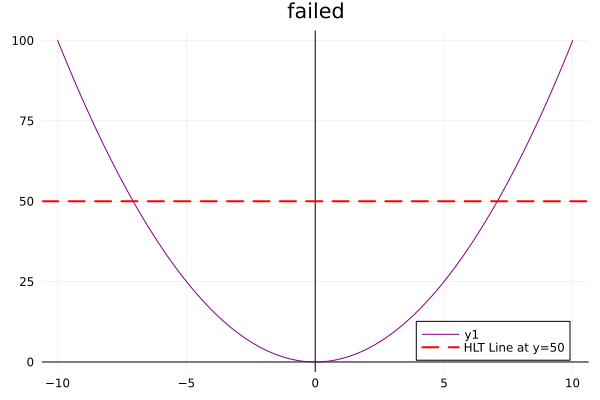

In [55]:
x = -10:0.1:10
fc(x) = x^2
plot(x,fc,color=:purple, framestyle=:zerolines, title="failed")
hline!([50], label="HLT Line at y=50", color=:red, linestyle=:dash, lw=2)

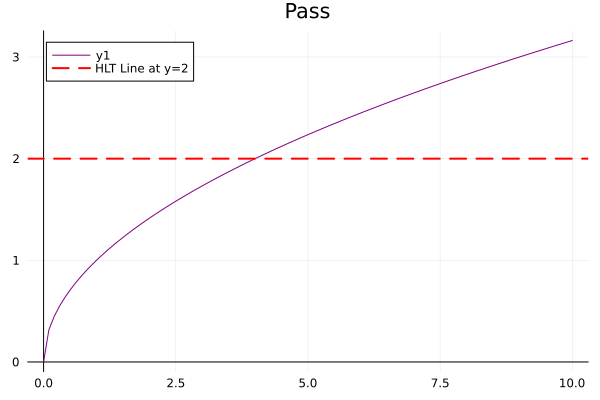

In [56]:
x = 0:0.1:10
fc(x) = sqrt.(x)
plot(x,fc,color=:purple, framestyle=:zerolines, title="Pass")
hline!([2], label="HLT Line at y=2", color=:red, linestyle=:dash, lw=2)

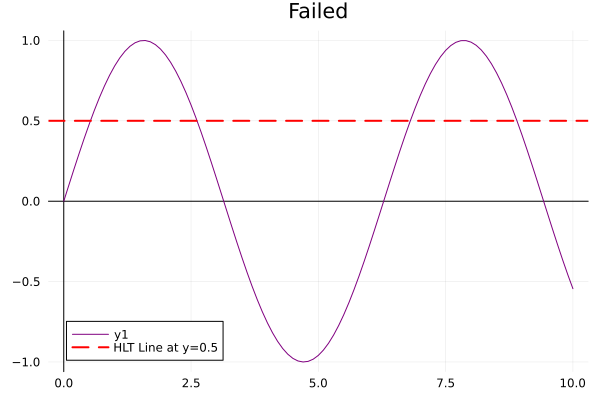

In [57]:
x = 0:0.1:10
fc(x) = sin.(x)
plot(x,fc,color=:purple, framestyle=:zerolines, title="Failed")
hline!([0.5], label="HLT Line at y=0.5", color=:red, linestyle=:dash, lw=2)


<a id="algebraic-derivation-of-inverse"></a>
#### 2.2.2.2 Algebraic Derivation of Inverse

**Mathematical Concept:**
Generating an inverse function demands substituting dependent/independent variables systematically, achieving symmetry across the $y=x$ axis.
$$ y = f(x) \implies x = f(y) \implies y = f^{-1}(x) $$

**Modeling Objective:**
Automate the variable inversion algorithm symbolically and visualize mathematical mirror-symmetry inherently.

[↑ Back to Table of Contents](#table-of-contents)

In [58]:
@syms x y 

fc(x) = x^5 + 10
display(f(x))
eq = x ~ f(y)
display(eq)
f_inverse = solve(eq,y)[1]

1
─
x

    1
x = ─
    y

1
─
x

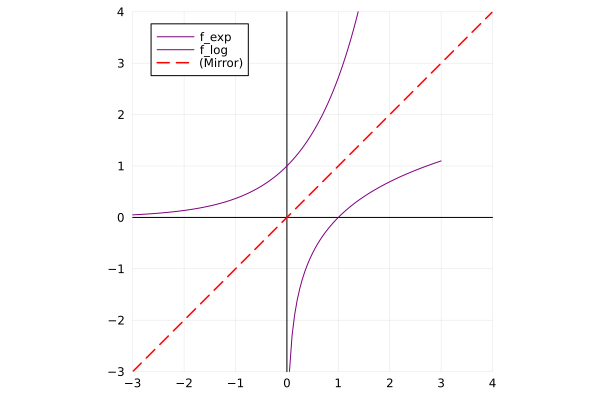

In [59]:
x_exp = -3:0.05:3
f_exp(x) = exp.(x)
plot(x_exp,f_exp,color=:purple,label="f_exp", framestyle=:zerolines, xlims=(-3, 4), ylims=(-3, 4),aspect_ratio=:equal)

x_log = 0.05:0.05:3
f_log(x) = log.(x)
plot!(x_log,f_log,color=:purple,label="f_log", framestyle=:zerolines)

plot!(-3:4, -3:4, label="(Mirror)", color=:red, linestyle=:dash, lw=1.5)
